# <span style="color:blue">Workshop 6: Competitive Coevolution with fitness sharing</span>

## <span style="color:#0073e6">Learning objectives</span>

- To implement a simple competitive coevolutionary algorithm using DEAP
- To understand how the populations interact and the impact of changing parameters in each population
- Implement a common version of fitness sharing (diversity measure)

# <span style="color:blue">Exercise 2: Diversity measures and general strategies</span>

You can see from Exercise 1 that short-term strategies and cycling can occur a lot. This is simply a property of this problem. However, transitivity can be a real issue when it comes to other problems. As you have seen in the lectures, diversity measures can help with not only this, but with evolvability in general (and are particularly important for coevolution and multi-objective evolution).

Fitness sharing is a commonly used diversity method that we will implement. Although it will not make much difference for this problem, the intention here is to understand how to implement it for this problem.

Here is the pseudocode for how you could implement it here. To calculate the shared fitness for individual i:

```
alpha = 0.5
sigma = 5

res = 0
for each individual j in the population
    calculate the genotype distance from i to j
    if distance < sigma
        res += 1 – (distance/sigma)**alpha
fitness = (original_fitness / res),    
```

For our binary genomes, we can calculate the difference between genomes using the Hamming distance, which simply returns the number of positions where the two individuals differ. Below is a Python implementation of Hamming distance between two genotypes (s1 and s2):

In [1]:
def hamming(s1, s2):
    assert len(s1) == len(s2)
    return sum(c1 != c2 for c1, c2 in zip(s1, s2))

- Plot the results in the same way that you did for Exercise 1
- Note that even with this, an alternative mediocre stable scenario may also be possible in which populations “speciate” such that they exhibit a number of different sub-optimal strategies that together form a stable combination.

# <span style="color:Blue">Code for the competitive coevolution with fitness sharing example</span>

Most of the code here is the same as (or very similar to) the code in co-evolution example 1. The main difference is the addition of the fitness sharing after the evaluation of individuals.

In [2]:
!pip install deap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 2.3 MB/s eta 0:00:00


In [3]:
import random
from deap import base
from deap import creator
from deap import tools
import numpy as np
import sys
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
from IPython import display

In [5]:
#Both parasite and host populations are trying to maximise their fitness
#So we can use creator.FitnexxMax for both ParasiteIndividual and HostIndividual
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("ParasiteIndividual", list, fitness=creator.FitnessMax)
creator.create("HostIndividual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

#Genes are going to be random {0, 1] integers
toolbox.register("attr_bool", random.randint, 0, 1)

#Register the Individual types - both are a list of 100 Boolean values
NUM_GENES = 100
toolbox.register("ParasiteIndividual", tools.initRepeat, creator.ParasiteIndividual, toolbox.attr_bool, NUM_GENES)
toolbox.register("HostIndividual", tools.initRepeat, creator.HostIndividual, toolbox.attr_bool, NUM_GENES)

#Register the two Population types - both are a list of their respective individuals
toolbox.register("HostPopulation", tools.initRepeat, list, toolbox.HostIndividual)
toolbox.register("ParasitePopulation", tools.initRepeat, list, toolbox.ParasiteIndividual)

In [6]:
def evalHost(individual):
    #To evaluate the fitness of a Host individual, we pair it with N random parasites
    #In this case N = 5
    fit = 0.0
    numOpponents = 5

    #Select N random opponents from the parasite population
    opponentIndexes = np.random.choice(len(popParasite), size=numOpponents, replace=False)
    opponents = [popParasite[i] for i in opponentIndexes]

    #For each opponent we are going to calculate a fitness of the host
    # by counting either NON-matching 1s or NON-matching 0s
    for opp in opponents:
        #Count the number of 1s in the parassite by summing the individual's genes
        x = sum(opp)

        #For this opponent, calculate the probability we will match against 1s
        #NOTE: This is inside the loop because we look at the Parasite 1s, which are different every time
        p = 0.5 * ( 1 + np.tanh( (x - 50) / 7 ) )
        if random.random() < p:
            matchingOnes = True
        else:
            matchingOnes = False

        #Step through the genes and either match 1s or match 0s
        for i in range(len(individual)):
            #If we are matching 1s, and the host has a 0, add to fitness
            if matchingOnes and opp[i] == 1 and individual[i] == 0:
                fit += 1
            #If we are matching 0s, and the host has a 1, add to fitness
            elif not(matchingOnes) and opp[i] == 0 and individual[i] == 1:
                fit += 1

    #We have added fitnesses over N opponents, so divide by N to scale the fitness
    return (fit/numOpponents),



In [7]:
def evalParasite(individual):
    #To evaluate the fitness of a Parasite individual, we pair it with N random Hosts
    #In this case N = 5
    fit = 0.0
    numOpponents = 5

    #Calculate the probability we will match against 1s
    #NOTE: This is outside the loop because we look at the Parasite 1s, which are the same every time
    x = sum(individual)
    p = 0.5 * ( 1 + np.tanh( (x - 50) / 7 ) )
    if random.random() < p:
        matchingOnes = True
    else:
        matchingOnes = False

    # Select numOpponents random individuals from the host population
    opponentIndexes = np.random.choice(len(popHost), size=numOpponents, replace=False)
    opponents = [popHost[i] for i in opponentIndexes]

    #For each opponent we are going to calculate a fitness of the Parasite
    # by counting either MATCHING 1s or MATCHING 0s
    for opp in opponents:
        #Step through the genes and either match 1s or match 0s
        for i in range(len(individual)):
            if individual[i] == opp[i]:
                if matchingOnes and opp[i] == 1 and individual[i] == 1:
                    fit += 1
                elif not(matchingOnes) and opp[i] == 0 and individual[i] == 0:
                    fit += 1

    return (fit/numOpponents),

We are using different mutation probabilities and tournament size here, compared to example 1, but this should not have too much effect on the outcome.

In [18]:
toolbox.register("evaluateHost", evalHost)
toolbox.register("evaluateParasite", evalParasite)
toolbox.register("mutateHost", tools.mutFlipBit, indpb=0.1)
toolbox.register("mutateParasite", tools.mutFlipBit, indpb=0.1)
toolbox.register("select", tools.selTournament, tournsize=6)

This is the code to implement fitness sharing.

There are three functions:


1.   `hamming_distance(s1, s2)` is how we calculate the similarity between two individuals. In this case it's based on counting the number of non-matching genes, but any other method could be used.
2.   `sharing(distance, sigma, alpha)` takes a distance and the chosen parameters and returns the contribution to the overall scaling for that distance.
3.   `shared_fitness(individual, population, sigma, alpha)` takes an individual and the relevant population, calculates the distance from every other individual in the population, and sums the individual contributions to give the denominator or scaling factor applied to that individual.







In [19]:
# For this problem, we know that the Hamming distance will be between 0 (no difference) and the number of genes (100 - entirely different)
def hamming_distance(s1, s2):
    assert len(s1) == len(s2)
    return sum(c1 != c2 for c1, c2 in zip(s1, s2))

# Sigma is the minimum distance for sharing
# Alpha is the sharing parameter for how much to penalize similar solutions
# With sigma set to 5 we will only penalize our individual for being similar to individuals within a hamming distance of 5
def sharing(distance, sigma, alpha):
    res = 0
    if distance < sigma:
        res += 1 - (distance/sigma)**alpha
    return res

def shared_fitness(individual, population, sigma = 5, alpha = 0.5):
    num = individual.fitness.values[0]

    dists = [hamming_distance(individual, x) for x in population]
    res = [sharing(d, sigma, alpha) for d in dists]
    den = sum(res)

    return num/den,

In [10]:
#We define the population size - in this case, both host and parasite populations will be the same size
POPSIZE = 50
NGEN = 200
#random.seed(99)

#Create both host and parasite populations
popHost = toolbox.HostPopulation(n=POPSIZE)
popParasite = toolbox.ParasitePopulation(n=POPSIZE)

In evaluting the fitness of individuals, we now have an extra step.

For each population, we calculate the individual fitnesses as before. We then take the individuals one by one, calculate the scaling and the new fitness for that individual.

We need to do this to set the intial fitnesses, and then every time around the main GA loop.

In [20]:
# Evaluate the entire host population's basic fitness
fitnessesHost = map(toolbox.evaluateHost, popHost)
for ind, fit in zip(popHost, fitnessesHost):
    ind.fitness.values = fit

# Evaluate the entire host population's shared fitness (using fitness sharing)
for ind in popHost:
    ind.fitness.values = shared_fitness(ind, popHost)

# Evaluate the entire parasite population's basic fitness
fitnessesParasite = map(toolbox.evaluateParasite, popParasite)
for ind, fit in zip(popParasite, fitnessesParasite):
    ind.fitness.values = fit

for ind in popParasite:
    ind.fitness.values = shared_fitness(ind, popParasite)

-- End of coevolution --


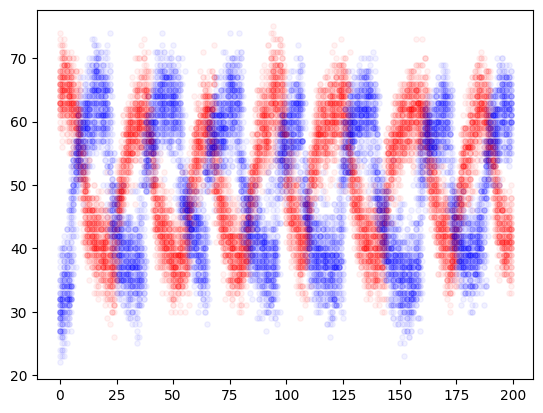

In [21]:
# Begin the evolution generations
for g in range(NGEN):
    #print("-- Generation %i --" % g)

    # ----- HOSTS --------
    offspringHost = toolbox.select(popHost, len(popHost))
    offspringHost = list(map(toolbox.clone, offspringHost))

    for mutant in offspringHost:
        toolbox.mutateHost(mutant)

    fitnessesHost = map(toolbox.evaluateHost, offspringHost)
    for ind, fit in zip(offspringHost, fitnessesHost):
        ind.fitness.values = fit

    # Evaluate the entire host population's shared fitness (using fitness sharing)
    for ind in popHost:
        ind.fitness.values = shared_fitness(ind, popHost)

    # ----- PARASITES --------
    offspringParasite = toolbox.select(popParasite, len(popParasite))
    offspringParasite = list(map(toolbox.clone, offspringParasite))

    for mutant in offspringParasite:
        toolbox.mutateParasite(mutant)

    fitnessesParasite = map(toolbox.evaluateParasite, offspringParasite)
    for ind, fit in zip(offspringParasite, fitnessesParasite):
        ind.fitness.values = fit

    for ind in popParasite:
        ind.fitness.values = shared_fitness(ind, popParasite)

    #-- Reproduce both hosts and parasites --
    popHost[:] = offspringHost
    popParasite[:] = offspringParasite

    # Gather all the fitnesses in one list and print the stats
    fitsHost = [ind.fitness.values[0] for ind in popHost]
    fitsParasite = [ind.fitness.values[0] for ind in popParasite]
    #print ("Host: " + str(np.mean(fitsHost)) )
    #print ("Parasite: " + str(np.mean(fitsParasite)) )

    # Instead of loop make this a vector
    #for index in range(POPSIZE):
    gen = [g] * POPSIZE
    host = [sum(x) for x in popHost]
    parasite = [sum(x) for x in popParasite]
    plt.scatter( gen, host, color='red', s=15, alpha=0.05)
    plt.scatter( gen, parasite, color='blue', s=15, alpha=0.05)
    display.display(plt.gcf())
    display.clear_output(wait=True)


print("-- End of coevolution --")